# Neighbourhood enrichment

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

import sys
import pickle
from collections import defaultdict
from tqdm import tqdm
import seaborn as sns

## Generate adata

In [32]:
import os
from sklearn import preprocessing
import logging
logger = logging.getLogger()

def normalise(adata,quantile= 0.95):
    if isinstance(adata, sc.AnnData):
        data =  adata.X
    else:
        data = adata.copy()
    if np.all(data<=1):
        logger.warning('data seem already normalised, skipping normalisation :)')
        return adata
    q = np.nanquantile(data,q = quantile,axis = 0)
    data = data/q
    data[data>1] = 1
    if isinstance(adata, sc.AnnData):
        adata.X = data
        return adata
    else:
        return data

def quality_control(intensities,low_gene_active = 0.2,high_gene_active = 0.5):
    #Not using at the moment
    if 'pass_qc' in intensities.columns:
        return intensities['pass_qc']
    intensities_protein = intensities.iloc[:,1:intensities.columns.get_loc('label')]#proteins are from the second columns up to the column called label
    #For phenotyping , we  want the cells to express some markers, but not all together at the same time.
    #We are going to consider the set of markers that we use for phenotyping

    markers_4_phenotyping = ['CD14', 'CD16', 'CD163', 'Pan-keratin',
                             'CD11b', 'CD107a', 'CD45', 'CD44',
                             'CD366', 'FOXP3', 'CD4', 'E-Cadherin', 
                             'CD68', 'HLA-DR-DQ-DP', 'CD20', 'CD8a',
                             'Beta-Catenin', 'B7-H4', 'Granzyme-B', 'CD3',
                             'CD45RO', 'Alpha-SMA', 'Vimentin', 'CD31']
    intensities_protein =    normalise(intensities_protein,0.95)# reconsider this TODO
    A = intensities_protein.loc[:,markers_4_phenotyping]
    cond_few_genes_in_cell  = np.sum(discretise(A,thr = low_gene_active),axis=1)>0
    cond_many_genes_in_cell  = np.sum(discretise(A,thr = high_gene_active),axis=1)<11
    dna_count = intensities_protein[['DNA1', 'DNA2']].sum(axis = 1)
    dna_thr = np.quantile(dna_count,0.05)
    dna_cond = dna_count>dna_thr
    cond = cond_few_genes_in_cell& cond_many_genes_in_cell&dna_cond
    return cond

def generate_anndata_from_cell_table(cell_table_path = None,biosamples_path = None,save = False,normalise_key = None):
    '''
    Here I load the spatial data, which consists of the protein intensity per cell, and the geometry location of the cell. I use the cell type annotation from Pixie. I filter out images with less than 1000 cells 
    Also I remove cells with the lowest 5%
    
    '''
    base_dir = "../"
    
    if cell_table_path is None:
        cell_table_path = os.path.join(base_dir, 'segmentation', 'cell_table', 'cell_table_size_normalized_cell_labels.csv')
    if biosamples_path is None:
        biosamples_path = base_dir+'IMC_data/ExtraDocs/processed_response.csv'
    
    cell_table = pd.read_csv(cell_table_path,index_col=False)
    if 'cell_meta_cluster' in cell_table.columns:
        cell_table = cell_table[cell_table['cell_meta_cluster']!='Unassigned']#remove cells that have not been assigned yet

    if 'qc_pass' not in cell_table.columns:
        logger.info('Generating quality control mask')
        qc_pass = quality_control(cell_table)
        cell_table['qc_pass'] = qc_pass
        logger.info('writing the cell table file at '+cell_table_path)
        cell_table.to_csv(cell_table_path,index = False)

    biosamples =pd.read_csv(biosamples_path)
    intensities_protein = cell_table.iloc[:,2:cell_table.columns.get_loc('label')]#proteins are from the second columns up to the column called label
    #I don't think it is a good idea of using'Carboplatin_nuclear'. for small nuclei, the density shoot to high value
    #intensities_protein['Carboplatin'] = cell_table['Carboplatin_nuclear']
    logger.info('Finished loading, now create the anndata object')
    adata = sc.AnnData(intensities_protein, obsm={"spatial": cell_table[['centroid-0', 'centroid-1']].values})
    try:
        adata.obs['Pixie'] = pd.Categorical(cell_table.cell_meta_cluster.values.astype(str))
    except:
        print('cell type label not present')
    adata.obs['acquisition_ID'] = cell_table.fov.values
    adata.obs['Leap_ID'] = adata.obs.acquisition_ID.str.split('_',n = 1).str[0].str.upper()
    adata.obs['Leap_ID'] = adata.obs.Leap_ID.str[:7]#leap_ID should be Leap123, anything more is stripped
    adata.obs = adata.obs.reset_index().merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1).set_index('index')#merging the metadata info, so that patient response is propagated to eaxch cell
    adata.obs['qc_pass'] = cell_table['qc_pass'].values
    #adata = adata[adata.obs.Keep=='y']
    adata.raw = adata#raw data are unfiltered and unnormalised
    
    adata.X[np.isnan(adata.X)] =0#the nan comes when a  segmented file does not have the corresponding channel tiff file. That happened for the Carboplatin on a release that dates to Jan 24. On a new full process of data, check that this is not required anymore
    sc.pp.log1p(adata,copy = False)
    if normalise_key is None:
        #Normalise each channel independently by quantile
        adata = normalise(adata,quantile=0.95) # Consider removing
    else:
        if normalise_key in adata.obs.columns:
            normalise_by_group(adata,group_key = normalise_key,quantile=0.95)
        else:
            raise ValueError(normalise_key+' not in adata.obs.columns')
    adata.layers['scaled'] = preprocessing.StandardScaler().fit_transform(adata.X)
    #sc.tl.pca(adata,layer='scaled')

    if save:
        data_folder = '~/Boston/Analysis/data/'
        filename = 'sc_protein.h5ad'
        if not os.path.exists(data_folder):
            os.makedirs(data_folder)

            adata.write(data_folder+filename)

    return adata
generate_anndata_from_ark_analysis = generate_anndata_from_cell_table

In [33]:
adata = generate_anndata_from_ark_analysis(cell_table_path='/home/luciana/Boston/post_clusteringki67/updated_cell_table_Ki67.csv',biosamples_path='/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/CleanCohort_Metadata.csv')

/home/luciana/anaconda3/envs/squidpy/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [34]:
nonresponderpp = adata[adata.obs['Response']=='Non-Responder']

## Generate the matrix of contact for each fov

In [35]:
###DO NOT RUN if unsure. Data are saved
def neighbours(fovs):
    '''It returns the matrix of contact for each fov'''
    store = {}    
    for ID in  set(fovs):
        sub_adata = adata[adata.obs.acquisition_ID==ID]#select one acquisition
        sq.gr.spatial_neighbors(sub_adata,coord_type='grid')
        sq.gr.nhood_enrichment(sub_adata, cluster_key='Pixie')
        A = sub_adata.uns['Pixie_nhood_enrichment']['zscore']
        a = np.array(sub_adata.obs['Pixie'].cat.categories)#label list
        fov_neighbour = pd.DataFrame(A,index=a,columns=a)
        store[ID]=fov_neighbour.fillna(0)
    return store

In [36]:
neigh_all = neighbours(nonresponderpp.obs.acquisition_ID.drop_duplicates())

with open('neighbours_matrix.pkl', 'wb') as f:
    pickle.dump(neigh_all, f)

/home/luciana/anaconda3/envs/squidpy/lib/python3.10/site-packages/squidpy/gr/_utils.py:193: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


  0%|          | 0/1000 [00:00<?, ?/s]

/home/luciana/anaconda3/envs/squidpy/lib/python3.10/site-packages/squidpy/gr/_nhood.py:182: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/home/luciana/anaconda3/envs/squidpy/lib/python3.10/site-packages/squidpy/gr/_utils.py:193: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


  0%|          | 0/1000 [00:00<?, ?/s]

/home/luciana/anaconda3/envs/squidpy/lib/python3.10/site-packages/squidpy/gr/_utils.py:193: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


...

  0%|          | 0/1000 [00:00<?, ?/s]

/home/luciana/anaconda3/envs/squidpy/lib/python3.10/site-packages/squidpy/gr/_utils.py:193: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


  0%|          | 0/1000 [00:00<?, ?/s]

/home/luciana/anaconda3/envs/squidpy/lib/python3.10/site-packages/squidpy/gr/_utils.py:193: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


  0%|          | 0/1000 [00:00<?, ?/s]

In [37]:
sample=nonresponderpp#nonresponderpp#pre
labels_list = sample.obs.Pixie.unique()
X = []
ids = []
core_ids = set(sample.obs.acquisition_ID)
for id,tb in neigh_all.items():
    if id not in core_ids:
        continue
    temp_matrix = pd.DataFrame(0.,index = labels_list,columns=labels_list)
    sub_list = tb.index#label list
    tb.replace([np.inf, -np.inf], np.nan, inplace=True) # convert inf to nan, next line everything is replaced with 0
    temp_matrix.loc[sub_list,sub_list]=tb
    temp_values = temp_matrix.values
    X +=[temp_values]
    ids+=[id]
y = np.vectorize(dict(sample.obs[['acquisition_ID','Sample_Type_(pre/post treatment)']].values).get)(ids) #Change for 'Response' when analysing 'pre'
X = np.array(X)

## Plot

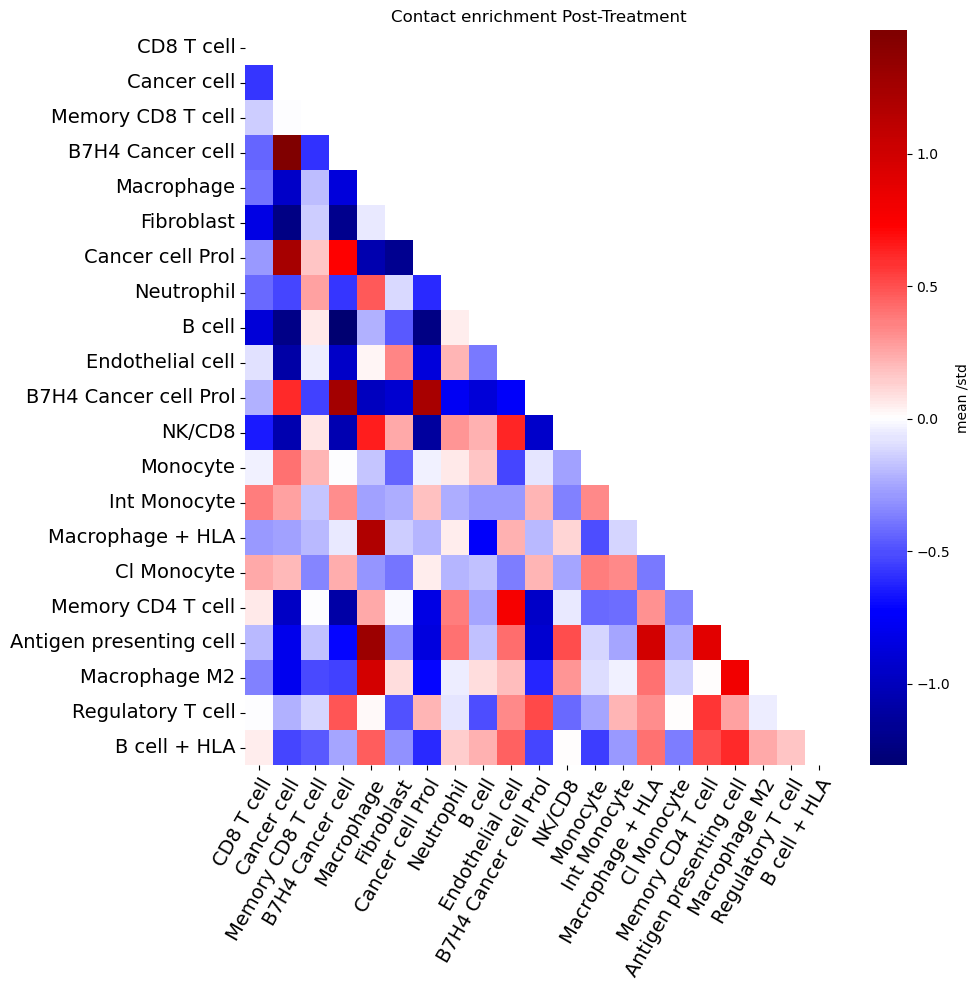

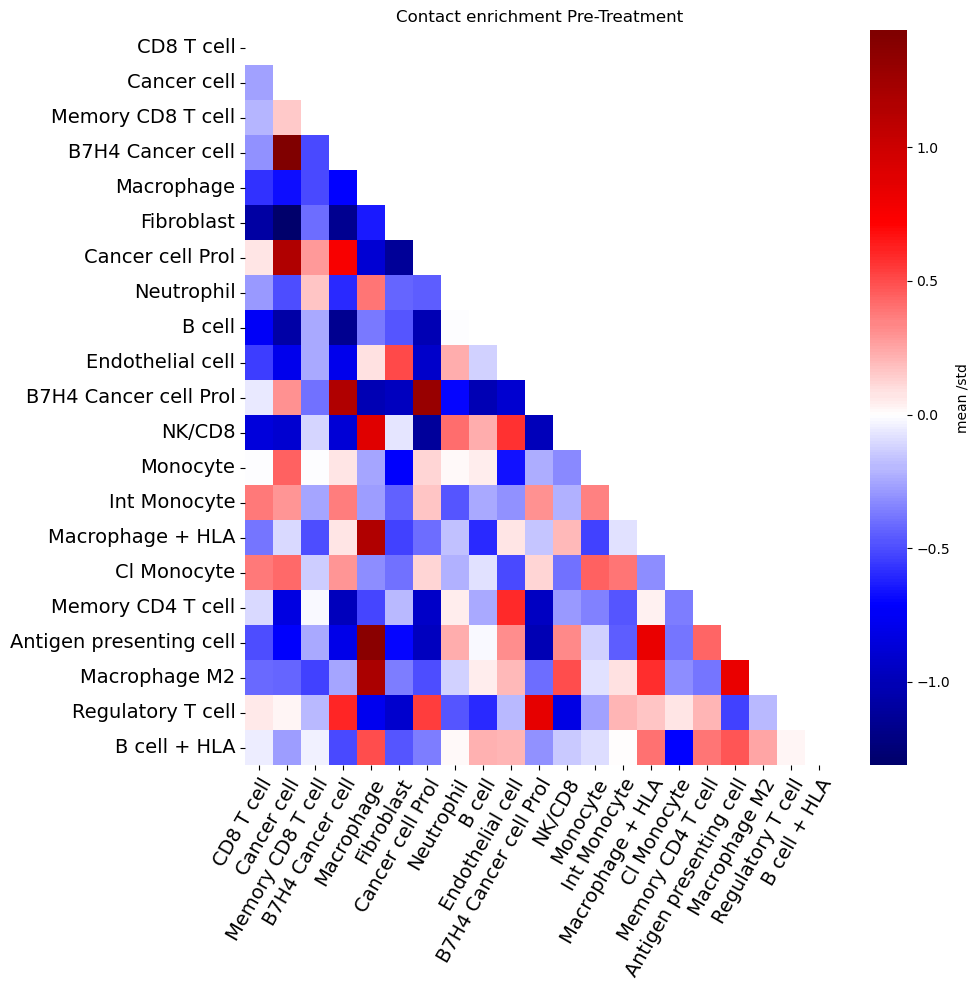

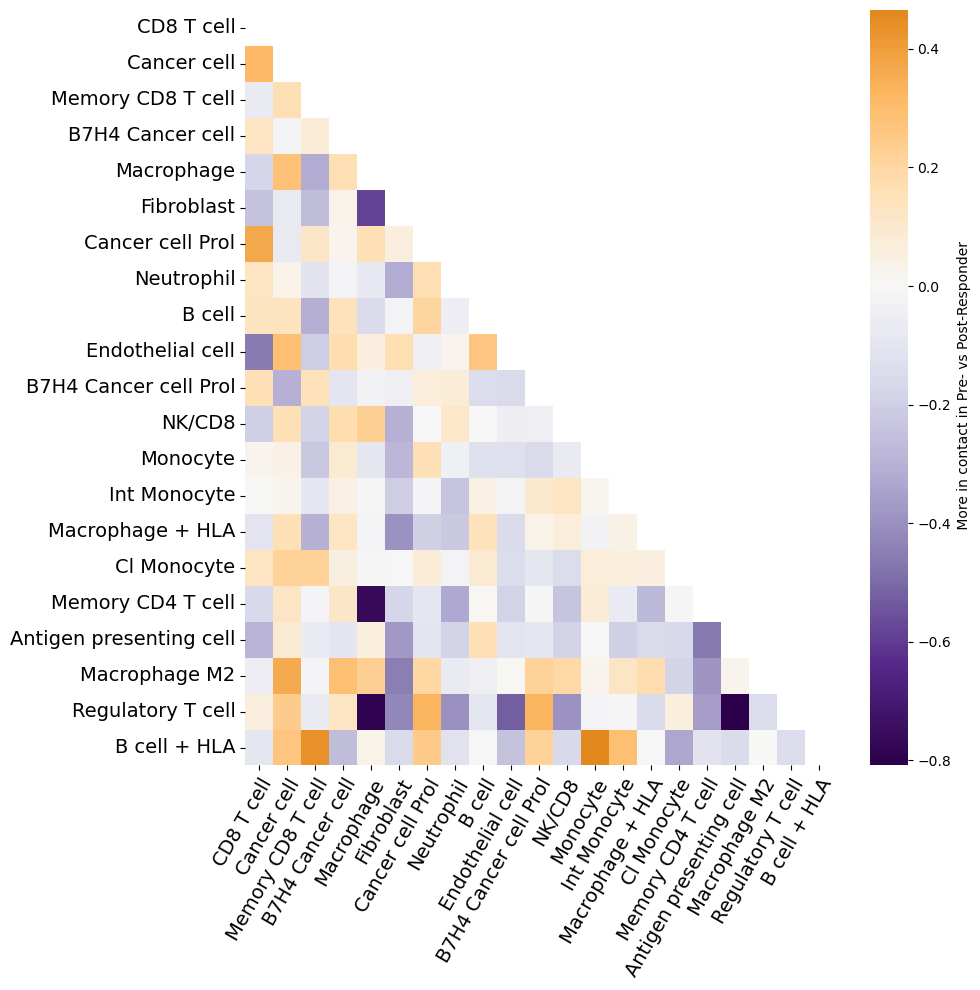

In [38]:
aux = X[y == 'post']
mean_nR = pd.DataFrame((np.nanmean(aux,axis = 0))/np.nanstd(aux,axis = 0),index = labels_list,columns=labels_list)
# Create a mask using numpy's triu function
mask1 = np.triu(np.ones_like(mean_nR, dtype=bool))
np.fill_diagonal(mean_nR.values,0)

aux = X[y == 'pre']
mean_pCr = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list,columns=labels_list)
# Create a mask using numpy's triu function
mask2 = np.triu(np.ones_like(mean_pCr, dtype=bool))
np.fill_diagonal(mean_pCr.values,0)


plt.figure(figsize = (10,10))
plt.title('Contact enrichment Post-Treatment')
vmax = mean_nR.abs().to_numpy().max()#vmin = -2.15,vmax = 2.15,
sns.heatmap(mean_nR,cmap='seismic',xticklabels=True,yticklabels=True,cbar = True,cbar_kws={'label':'mean /std'}, mask=mask1, center=0)
_ = plt.xticks(rotation=60,fontsize = 14,ha='right',rotation_mode='anchor')
_ = plt.yticks(fontsize = 14)
plt.tight_layout()
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/Neigh_NonRes_post.png',transparent = False, format='png', dpi=600, bbox_inches='tight')

plt.figure(figsize = (10,10))
plt.title('Contact enrichment Pre-Treatment')
vmax = mean_pCr.abs().to_numpy().max()
sns.heatmap(mean_pCr,cmap='seismic',xticklabels=True,yticklabels=True,cbar =True,cbar_kws={'label':'mean /std'}, mask=mask2, center=0)
_ = plt.xticks(rotation=60,fontsize = 14,ha='right',rotation_mode='anchor')
_ = plt.yticks(fontsize = 14)
plt.tight_layout()
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/Neigh_NonRes_pre.png',transparent = False, format='png', dpi=600, bbox_inches='tight')


sub = mean_pCr-mean_nR

mask3 = np.triu(np.ones_like(sub, dtype=bool))
np.fill_diagonal(sub.values,0)


plt.figure(figsize = (10,10))
#'PuOr_r' colormap, 'RdYlGn'
sns.heatmap(sub,cmap='PuOr_r',xticklabels=True,yticklabels=True,cbar = True,cbar_kws={'label':' More in contact in Pre- vs Post-Responder'}, mask=mask3, center=0)#,vmin = -1,vmax = 1
_ = plt.xticks(rotation=60,fontsize = 14,ha='right',rotation_mode='anchor')
_ = plt.yticks(fontsize = 14)
plt.tight_layout()
#plt.savefig('/home/luciana/devices/Delta_Tissue/IMC/CleanCohort/Figures/New/Neigh_NonRes_prevspost.png',transparent = False, format='png', dpi=600, bbox_inches='tight')